# PII Detection & Classification Report

This notebook runs the project model and a baseline (Presidio) on `ai_data.csv`, then generates tables and plots for your report.

In [33]:
# Install dependencies (run once)
!python -m pip install presidio-analyzer matplotlib seaborn pandas scikit-learn tabulate
!python -m spacy download en_core_web_sm



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import os, sys, ast
from collections import Counter, defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


In [35]:
# Paths
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))  # repo root from ml_report_project
DATA_PATH = os.path.join(os.getcwd(), 'data', 'ai_data.csv')
OUT_DIR = os.path.join(os.getcwd(), 'outputs')
PLOTS_DIR = os.path.join(OUT_DIR, 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)

print('DATA_PATH:', DATA_PATH)
print('OUT_DIR:', OUT_DIR)


DATA_PATH: c:\Users\yasha\Downloads\22CS7-AnonBasedMiddleware\ml_report_project\data\ai_data.csv
OUT_DIR: c:\Users\yasha\Downloads\22CS7-AnonBasedMiddleware\ml_report_project\outputs


In [36]:
# Load data
df = pd.read_csv(DATA_PATH)
print(df.columns)
df.head(2)


Index(['0', '1'], dtype='object')


,0,1
0,"In today's modern world, where technology has ...","{'NAME_STUDENT': ['Richard', 'Chang'], 'EMAIL'..."
1,"In today's modern world, where technology has ...","{'NAME_STUDENT': [], 'EMAIL': ['tamaramorrison..."


In [37]:
# Utilities
def normalize_text(value: str) -> str:
    if value is None:
        return ''
    text = str(value).strip().strip('"').strip("'")
    return ' '.join(text.lower().split())

def load_gold_labels(raw_value):
    if raw_value is None or (isinstance(raw_value, float) and pd.isna(raw_value)):
        return []
    if isinstance(raw_value, dict):
        data = raw_value
    else:
        data = ast.literal_eval(str(raw_value))

    gold = []
    for label, items in data.items():
        if items is None:
            continue
        if isinstance(items, (list, tuple)):
            clean_items = [normalize_text(x) for x in items if normalize_text(x)]
            for item in clean_items:
                gold.append((item, label))
            if len(clean_items) > 1:
                joined = normalize_text(' '.join(clean_items))
                if joined:
                    gold.append((joined, label))
        else:
            item = normalize_text(items)
            if item:
                gold.append((item, label))
    return gold

def build_gold_maps(gold_list):
    gold_set = set()
    gold_labels_by_text = defaultdict(set)
    for text, label in gold_list:
        gold_set.add(text)
        gold_labels_by_text[text].add(label)
    return gold_set, gold_labels_by_text

def map_project_label(label: str):
    mapping = {
        'EMAIL': 'EMAIL',
        'PHONE': 'PHONE_NUM',
        'URL': 'URL_PERSONAL',
        'PERSON_NAME': 'NAME_STUDENT',
        'ADDRESS': 'STREET_ADDRESS',
        'IP_ADDRESS': 'ID_NUM',
        'ACCOUNT_ID': 'ID_NUM',
        'SSN': 'ID_NUM',
        'IBAN': 'ID_NUM',
    }
    return mapping.get(label)

def map_presidio_label(label: str):
    mapping = {
        'EMAIL_ADDRESS': 'EMAIL',
        'PHONE_NUMBER': 'PHONE_NUM',
        'URL': 'URL_PERSONAL',
        'PERSON': 'NAME_STUDENT',
        'USERNAME': 'USERNAME',
        'LOCATION': 'STREET_ADDRESS',
        'CREDIT_CARD': 'ID_NUM',
        'US_SSN': 'ID_NUM',
        'IP_ADDRESS': 'ID_NUM',
    }
    return mapping.get(label)

def compute_metrics(rows):
    tp = sum(r['tp'] for r in rows)
    fp = sum(r['fp'] for r in rows)
    fn = sum(r['fn'] for r in rows)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    return precision, recall, f1, tp, fp, fn


In [38]:
# Load project model
sys.path.insert(0, ROOT)
from apps.api.anonymizer import PIIAnonymizer
project_model = PIIAnonymizer()


In [39]:
# Load baseline (Presidio)
from presidio_analyzer import AnalyzerEngine
presidio = AnalyzerEngine()


In [40]:
# Run evaluation
per_row_detection = {"project": [], "presidio": []}
per_row_classification = {"project": [], "presidio": []}
per_label_counts = {
    "project": defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0}),
    "presidio": defaultdict(lambda: {"tp": 0, "fp": 0, "fn": 0}),
}
pred_type_counts = {"project": Counter(), "presidio": Counter()}
gold_type_counts = Counter()
sample_rows = []

for _, row in df.iterrows():
    text = str(row['0'])
    gold = load_gold_labels(row['1'])
    gold_set, gold_labels_by_text = build_gold_maps(gold)
    for _, lbl in gold:
        gold_type_counts[lbl] += 1

    project_raw = project_model.detect_pii(text)
    project_preds = [(normalize_text(t), map_project_label(lbl), lbl) for t, lbl, _, _ in project_raw]
    project_preds = [(t, mapped, raw) for t, mapped, raw in project_preds if t]

    presidio_raw = presidio.analyze(text=text, language="en")
    presidio_preds = [
        (normalize_text(text[r.start:r.end]), map_presidio_label(r.entity_type), r.entity_type)
        for r in presidio_raw
    ]
    presidio_preds = [(t, mapped, raw) for t, mapped, raw in presidio_preds if t]

    for t, mapped, raw in project_preds:
        pred_type_counts['project'][mapped or raw] += 1
    for t, mapped, raw in presidio_preds:
        pred_type_counts['presidio'][mapped or raw] += 1

    project_pred_texts = {t for t, _, _ in project_preds}
    presidio_pred_texts = {t for t, _, _ in presidio_preds}

    for name, pred_texts in [("project", project_pred_texts), ("presidio", presidio_pred_texts)]:
        tp = len(pred_texts & gold_set)
        fp = len(pred_texts - gold_set)
        fn = len(gold_set - pred_texts)
        per_row_detection[name].append({"tp": tp, "fp": fp, "fn": fn})

    for name, preds in [("project", project_preds), ("presidio", presidio_preds)]:
        tp = fp = fn = 0
        matched_gold = set()
        for t, mapped_label, _ in preds:
            if not mapped_label:
                continue
            gold_labels = gold_labels_by_text.get(t, set())
            if mapped_label in gold_labels:
                tp += 1
                matched_gold.add((t, mapped_label))
                per_label_counts[name][mapped_label]["tp"] += 1
            else:
                fp += 1
                per_label_counts[name][mapped_label]["fp"] += 1

        for t, labels in gold_labels_by_text.items():
            for label in labels:
                if (t, label) not in matched_gold:
                    fn += 1
                    per_label_counts[name][label]["fn"] += 1
        per_row_classification[name].append({"tp": tp, "fp": fp, "fn": fn})

    if len(sample_rows) < 5:
        sample_rows.append({
            'text': text[:200],
            'gold_labels': '; '.join(sorted({lbl for _, lbl in gold})),
            'project_pred_types': '; '.join(sorted({mapped or raw for _, mapped, raw in project_preds})),
            'presidio_pred_types': '; '.join(sorted({mapped or raw for _, mapped, raw in presidio_preds})),
        })


In [41]:
# Build summary tables
summary_rows = []
for name in ['project', 'presidio']:
    p, r, f1, tp, fp, fn = compute_metrics(per_row_detection[name])
    summary_rows.append({
        'model': name,
        'metric': 'detection_text_match',
        'precision': p,
        'recall': r,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
    })
    p, r, f1, tp, fp, fn = compute_metrics(per_row_classification[name])
    summary_rows.append({
        'model': name,
        'metric': 'classification_text_and_type',
        'precision': p,
        'recall': r,
        'f1': f1,
        'tp': tp,
        'fp': fp,
        'fn': fn,
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,model,metric,precision,recall,f1,tp,fp,fn
0,project,detection_text_match,0.454426,0.527647,0.488307,10764,12923,9636
1,project,classification_text_and_type,0.585774,0.619307,0.602074,17039,12049,10474
2,presidio,detection_text_match,0.411465,0.458824,0.433856,9360,13388,11040
3,presidio,classification_text_and_type,0.424925,0.566926,0.485761,16349,22126,12489


In [42]:
per_label_rows = []
for name in ['project', 'presidio']:
    for label, counts in per_label_counts[name].items():
        tp = counts['tp']; fp = counts['fp']; fn = counts['fn']
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        per_label_rows.append({
            'model': name,
            'label': label,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'tp': tp,
            'fp': fp,
            'fn': fn,
        })

per_label_df = pd.DataFrame(per_label_rows)
per_label_df.head(10)


,model,label,precision,recall,f1,tp,fp,fn
0,project,NAME_STUDENT,0.426988,0.909129,0.581068,8784,11788,878
1,project,EMAIL,0.980747,0.844603,0.907598,2598,51,478
2,project,ID_NUM,0.950570,0.339328,0.500125,1000,52,1947
3,project,PHONE_NUM,0.986288,0.680809,0.805561,2086,29,978
4,project,URL_PERSONAL,1.000000,0.842675,0.914621,2571,0,480
5,project,USERNAME,0.000000,0.000000,0.000000,0,0,2896
6,project,STREET_ADDRESS,0.000000,0.000000,0.000000,0,129,2817
7,presidio,EMAIL,0.980429,0.846879,0.908774,2605,52,471
8,presidio,URL_PERSONAL,0.082968,0.147909,0.106305,435,4808,2506
9,presidio,NAME_STUDENT,0.419537,0.944695,0.581037,10488,14511,614


In [43]:
# Type count table
type_counts_df = pd.DataFrame({
    'label': sorted(set(list(gold_type_counts.keys()) + list(pred_type_counts['project'].keys()) + list(pred_type_counts['presidio'].keys()))),
})
type_counts_df['gold_count'] = type_counts_df['label'].map(gold_type_counts).fillna(0).astype(int)
type_counts_df['project_pred_count'] = type_counts_df['label'].map(pred_type_counts['project']).fillna(0).astype(int)
type_counts_df['presidio_pred_count'] = type_counts_df['label'].map(pred_type_counts['presidio']).fillna(0).astype(int)
type_counts_df.head(10)


,label,gold_count,project_pred_count,presidio_pred_count
0,ARTWORK_TITLE,0,118,0
1,DATE_TIME,0,3051,3918
2,DRIVER_LICENSE,0,1031,0
3,EMAIL,2930,2649,2657
4,EU_VAT,0,31,0
5,EVENT_NAME,0,16,0
6,FACILITY_NAME,0,219,0
7,FINANCIAL_AMOUNT,0,5,0
8,IBAN_CODE,0,0,501
9,ID_NUM,2906,1052,746


In [44]:
# Save tables
summary_df.to_csv(os.path.join(OUT_DIR, 'summary_metrics.csv'), index=False)
per_label_df.to_csv(os.path.join(OUT_DIR, 'per_label_metrics.csv'), index=False)
type_counts_df.to_csv(os.path.join(OUT_DIR, 'type_counts.csv'), index=False)
pd.DataFrame(sample_rows).to_csv(os.path.join(OUT_DIR, 'sample_predictions.csv'), index=False)
summary_df


,model,metric,precision,recall,f1,tp,fp,fn
0,project,detection_text_match,0.454426,0.527647,0.488307,10764,12923,9636
1,project,classification_text_and_type,0.585774,0.619307,0.602074,17039,12049,10474
2,presidio,detection_text_match,0.411465,0.458824,0.433856,9360,13388,11040
3,presidio,classification_text_and_type,0.424925,0.566926,0.485761,16349,22126,12489


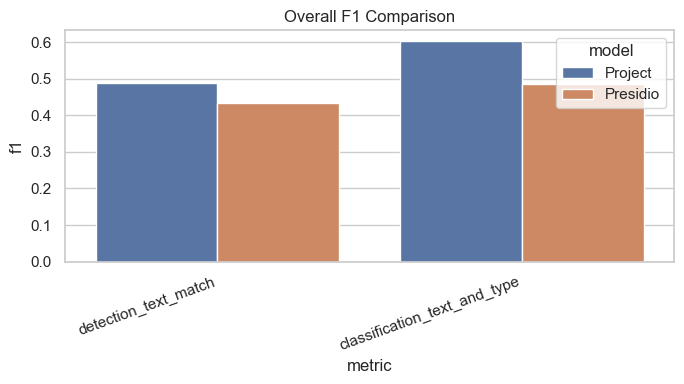

In [45]:
# Plot: overall F1
plt.figure(figsize=(7, 4))
plot_df = summary_df.copy()
plot_df['model'] = plot_df['model'].str.title()
sns.barplot(data=plot_df, x='metric', y='f1', hue='model')
plt.xticks(rotation=20, ha='right')
plt.title('Overall F1 Comparison')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'overall_f1.png'), dpi=200)
plt.show()


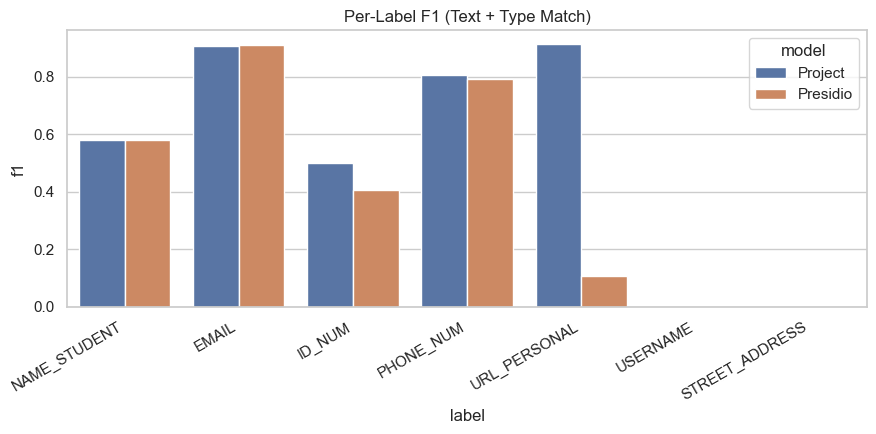

In [46]:
# Plot: per-label F1
if not per_label_df.empty:
    plt.figure(figsize=(9, 4.5))
    plot_df = per_label_df.copy()
    plot_df['model'] = plot_df['model'].str.title()
    sns.barplot(data=plot_df, x='label', y='f1', hue='model')
    plt.xticks(rotation=30, ha='right')
    plt.title('Per-Label F1 (Text + Type Match)')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'per_label_f1.png'), dpi=200)
    plt.show()


In [47]:
# Macro-average table
macro_rows = []
for name in ['project', 'presidio']:
    model_df = per_label_df[per_label_df['model'] == name]
    macro_rows.append({
        'model': name,
        'metric': 'macro_avg',
        'precision': model_df['precision'].mean() if not model_df.empty else 0.0,
        'recall': model_df['recall'].mean() if not model_df.empty else 0.0,
        'f1': model_df['f1'].mean() if not model_df.empty else 0.0,
    })
macro_df = pd.DataFrame(macro_rows)
macro_df


,model,metric,precision,recall,f1
0,project,macro_avg,0.620656,0.516649,0.529853
1,presidio,macro_avg,0.490494,0.410039,0.398800


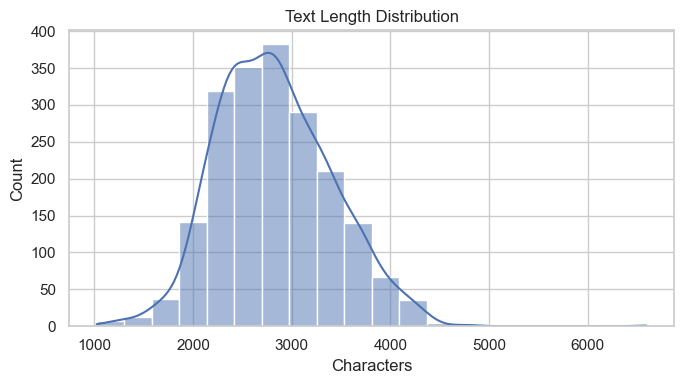

In [51]:
# Plot: text length distribution
plt.figure(figsize=(7, 4))
sns.histplot(df['0'].astype(str).str.len(), bins=20, kde=True)
plt.title('Text Length Distribution')
plt.xlabel('Characters')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'text_length_distribution.png'), dpi=200)
plt.show()
